<a href="https://colab.research.google.com/github/aaohl-lanlan/ia-ciberseguranca/blob/main/ia_ciberseguranca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Setup do Projeto (Aula 1)


**Dupla:** `Allan Accioly `  ·  `Lucas Chaves`

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
from pathlib import Path

# Raiz do projeto no Drive (ajuste o nome se quiser)
PROJETO = Path('/content/drive/MyDrive/ia-ciberseguranca')
SUBDIRS = ['data/raw', 'data/processed', 'notebooks', 'src', 'models', 'reports']

for d in SUBDIRS:
    (PROJETO / d).mkdir(parents=True, exist_ok=True)

print('Projeto em:', PROJETO)
!ls -la "{PROJETO}"

Projeto em: /content/drive/MyDrive/ia-ciberseguranca
total 20
drwx------ 4 root root 4096 Aug 13 13:23 data
drwx------ 2 root root 4096 Aug 13 13:23 models
drwx------ 2 root root 4096 Aug 13 13:23 notebooks
drwx------ 2 root root 4096 Aug 13 13:23 reports
drwx------ 2 root root 4096 Aug 13 13:23 src


In [3]:
import sys, platform
from importlib.metadata import version, PackageNotFoundError

print('Python :', sys.version.split()[0], '|', platform.platform())
print('-' * 40)

PACOTES = ['numpy', 'pandas', 'scikit-learn', 'scipy', 'matplotlib',
           'seaborn', 'imbalanced-learn', 'xgboost']
for p in PACOTES:
    try:
        print(f'{p:18s} {version(p)}')
    except PackageNotFoundError:
        print(f'{p:18s} (não instalado)')

Python : 3.12.13 | Linux-6.6.122+-x86_64-with-glibc2.35
----------------------------------------
numpy              2.0.2
pandas             2.2.2
scikit-learn       1.6.1
scipy              1.16.3
matplotlib         3.10.0
seaborn            0.13.2
imbalanced-learn   0.14.2
xgboost            3.3.0


In [4]:
%pip install -q imbalanced-learn xgboost

In [5]:
from importlib.metadata import version

PKGS = ['numpy', 'pandas', 'scikit-learn', 'scipy', 'matplotlib',
        'seaborn', 'imbalanced-learn', 'xgboost']

req = PROJETO / 'requirements.txt'
req.write_text('\n'.join(f'{p}=={version(p)}' for p in PKGS) + '\n')

print(req, 'gerado:\n')
print(req.read_text())

/content/drive/MyDrive/ia-ciberseguranca/requirements.txt gerado:

numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
scipy==1.16.3
matplotlib==3.10.0
seaborn==0.13.2
imbalanced-learn==0.14.2
xgboost==3.3.0



In [6]:
import os, random
import numpy as np

def set_seed(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except ModuleNotFoundError:
        pass

set_seed(42)
print('Seeds fixadas em 42')

Seeds fixadas em 42


In [7]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

X, y = make_classification(n_samples=10_000, n_features=20, n_informative=6,
                           weights=[0.98, 0.02], random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1).fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]

print(f'Positivos no teste : {y_te.mean():.2%}')
print(f'ROC-AUC            : {roc_auc_score(y_te, proba):.3f}')
print(f'PR-AUC             : {average_precision_score(y_te, proba):.3f}   <- a que importa aqui')

Positivos no teste : 2.53%
ROC-AUC            : 0.791
PR-AUC             : 0.547   <- a que importa aqui


In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJETO = Path('/content/drive/MyDrive/ia-ciberseguranca')
(PROJETO / 'models').mkdir(parents=True, exist_ok=True)
(PROJETO / 'data' / 'test').mkdir(parents=True, exist_ok=True)

print('Coloque converted_keras.zip em:', PROJETO / 'models')
print('Coloque as imagens de teste em: ', PROJETO / 'data' / 'test' / '<classe>')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Coloque converted_keras.zip em: /content/drive/MyDrive/ia-ciberseguranca/models
Coloque as imagens de teste em:  /content/drive/MyDrive/ia-ciberseguranca/data/test/<classe>


In [4]:
# Descompacta o modelo exportado do Teachable Machine
import zipfile

ZIP = PROJETO / 'models' / 'converted_keras.zip'
DEST = PROJETO / 'models'
with zipfile.ZipFile(ZIP) as z:
    z.extractall(DEST)

H5     = DEST / 'keras_model.h5'
LABELS = DEST / 'labels.txt'
print('Modelo :', H5.exists(), H5)
print('Labels :', LABELS.exists(), LABELS)

Modelo : True /content/drive/MyDrive/ia-ciberseguranca/models/keras_model.h5
Labels : True /content/drive/MyDrive/ia-ciberseguranca/models/labels.txt


In [5]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"   # carrega modelos Keras 2 (Teachable Machine) sob TF novo
%pip install -q tf_keras

import tensorflow as tf
from tensorflow.keras.layers import DepthwiseConv2D
print('TensorFlow', tf.__version__)

# Patch: versões antigas salvam 'groups' no DepthwiseConv2D; o Keras novo não entende
class PatchedDepthwiseConv2D(DepthwiseConv2D):
    def __init__(self, *args, **kwargs):
        kwargs.pop('groups', None)
        super().__init__(*args, **kwargs)

model = tf.keras.models.load_model(
    H5, compile=False,
    custom_objects={'DepthwiseConv2D': PatchedDepthwiseConv2D})

class_names = [l.strip().split(' ', 1)[-1]
               for l in open(LABELS, encoding='utf-8') if l.strip()]
print('Classes:', class_names)
model.summary()

TensorFlow 2.20.0
Classes: ['Cachorro', 'Gato']
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 1280)              410208    
                                                                 
 sequential_3 (Sequential)   (None, 2)                 128300    
                                                                 
Total params: 538508 (2.05 MB)
Trainable params: 524428 (2.00 MB)
Non-trainable params: 14080 (55.00 KB)
_________________________________________________________________


In [6]:
import numpy as np
from PIL import Image, ImageOps

try:
    RESAMPLE = Image.Resampling.LANCZOS
except AttributeError:
    RESAMPLE = Image.LANCZOS

def carregar_imagem(caminho, tamanho=224):
    img = Image.open(caminho).convert('RGB')
    img = ImageOps.fit(img, (tamanho, tamanho), RESAMPLE)
    arr = np.asarray(img).astype(np.float32)
    return (arr / 127.5) - 1.0            # normalização do Teachable Machine

def prever(caminho):
    x = carregar_imagem(caminho)[None, ...]
    probs = model.predict(x, verbose=0)[0]
    i = int(np.argmax(probs))
    return class_names[i], float(probs[i]), probs

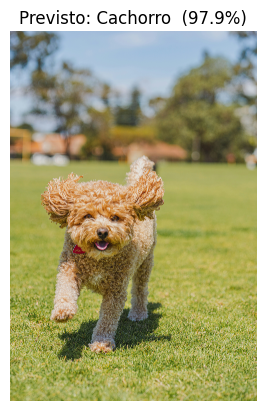

In [7]:
# Teste rápido com UMA imagem (aponte para um arquivo do seu data/test)
import matplotlib.pyplot as plt

exemplos = list((PROJETO / 'data' / 'test').rglob('*'))
exemplos = [p for p in exemplos if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
assert exemplos, 'Coloque imagens em data/test/<classe>/ antes de rodar.'

alvo = exemplos[2]
classe, conf, _ = prever(alvo)
plt.imshow(Image.open(alvo)); plt.axis('off')
plt.title(f'Previsto: {classe}  ({conf:.1%})')
plt.show()

Imagens de teste : 30
Acurácia no teste: 86.7%

              precision    recall  f1-score   support

    Cachorro       0.82      0.93      0.88        15
        Gato       0.92      0.80      0.86        15

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



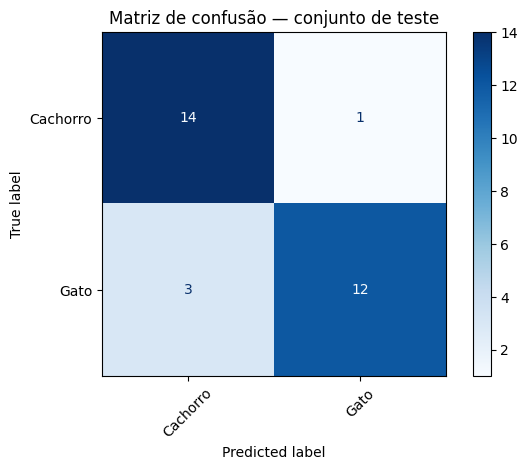

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

TEST_DIR = PROJETO / 'data' / 'test'
y_true, y_pred = [], []

for classe_dir in sorted(d for d in TEST_DIR.iterdir() if d.is_dir()):
    for img in classe_dir.glob('*'):
        if img.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
            continue
        nome, _, _ = prever(img)
        y_true.append(classe_dir.name)
        y_pred.append(nome)

print(f'Imagens de teste : {len(y_true)}')
print(f'Acurácia no teste: {accuracy_score(y_true, y_pred):.1%}\n')
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=class_names)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation=45)
plt.title('Matriz de confusão — conjunto de teste')
plt.tight_layout(); plt.show()

# Discussão da atividade :
**pergunta:**  A acurácia no **nosso teste** ficou próxima da que o Teachable Machine mostrou? Se caiu, **por quê**?

**Resposta:** Sim, mas apresentou certa queda devido ao maior número de imagens de teste que possivelmente fugiram do padrão das imagens de treino.
- - - - -
**Pergunta:**   Onde cada etapa do **pipeline** apareceu nesta aula?

**Resposta:** Coleta e preparação dos dados, configuração da célula, descompactação, carregamento das imagens, representação com MobileNet, carregamento do modelo, previsão, treinamento no TM, avaliação do modelo e métricas.
- - - - -

**Pergunta:** Que classe o modelo mais confunde? O que isso sugere sobre as *features* que ele aprendeu?

**Resposta:** classe Gato, que ela requer mais imagens de treino para se adaptar a diferentes composições e posições que estão interferindo com suas features.

In [16]:
# Guardar o modelo do projeto para reuso na aula 10 (ataques de evasão)
import shutil
shutil.copy(H5, PROJETO / 'models' / 'modelo_aula2.h5')
(PROJETO / 'models' / 'labels_aula2.txt').write_text('\n'.join(class_names) + '\n')
print('Modelo salvo em models/modelo_aula2.h5 — não apague, será atacado na aula 10.')

Modelo salvo em models/modelo_aula2.h5 — não apague, será atacado na aula 10.
